# Лабораторная работа №2

Студент группы **ИВТб-2301-05-00**
Ковальский Иван Иванович
Вариант 10

## Задание

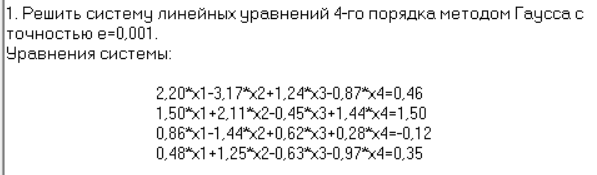

In [1]:
import numpy as np
import copy
np.random.seed(105)

# Функция нахождения невязки
def calc_residual(A, x, b):
    c = np.dot(A, x) - b # невязка c =  A*x - B
    return c

## Задание 1. Метод Гаусса 
Решить систему 4-го порядка методом Гаусса с выбором и без выбора главного элемента с точностью $\epsilon = 0.001$.
Сравнить, привести пример, где метод без выбора дает сбой.

In [2]:
A1 = np.array(
    [
        [2.20, -3.17, 1.24, -0.87],
        [1.50, 2.11, -0.45, 1.44],
        [0.86, -1.44, 0.62, 0.28],
        [0.48, 1.25, -0.63, -0.97],
    ]
)

b1 = np.array([0.46, 1.50, -0.12, 0.35])

### Метод Гаусса без выбора главного элемента

In [3]:
def gauss_no_pivoting(A_in, b_in):
    A = A_in.copy() #Матрицы исходной системы
    b = b_in.copy()
    n = len(b) #Сколько будет шагов

    # Прямой ход - обнуление снизу элемента
    for k in range(n - 1):
        for i in range(k + 1, n):

            factor = A[i, k] / A[k, k] # коэффициент на который надо умножить строку

            A[i, k:] =A[i, k:] - factor * A[k, k:]

            b[i] =b[i] - factor * b[k]
    # Обратный хож
    x = np.zeros(n)
    for i in range(n - 1, -1, -1): # идём снизу вверх
        x[i] = (b[i] - # из свободного члены вычитаем:
                np.dot(A[i, i + 1 :], x[i + 1 :])#умножаемые элементы правее диагонали на найденые коэффициенты
                ) / A[i, i] #делим на коэффициент икса, чтобы получить x=...
    return x


### Метод Гаусса с выбором главного элемента по столбцу

In [4]:
def gauss_with_pivoting(A_in, b_in):
    A = A_in.copy()
    b = b_in.copy()
    n = len(b)

    # Прямой ход
    for k in range(n - 1):
        # Ищем строку с максимальным по модулю элементом в текущем столбце
        max_row = np.argmax(np.abs(A[k:, k])) + k

        # Меняем строки местами
        if max_row != k:
            A[[k, max_row]] = A[[max_row, k]]
            b[[k, max_row]] = b[[max_row, k]]

        for i in range(k + 1, n):
            factor = A[i, k] / A[k, k]
            A[i, k:] = A[i, k:] - factor * A[k, k:]
            b[i] = b[i] - factor * b[k]

    # Обратный ход
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - np.dot(A[i, i + 1 :], x[i + 1 :])) / A[i, i]
    return x

### Ответ задание 1

In [5]:
x_gauss_no_piv = gauss_no_pivoting(A1, b1)
x_gauss_piv = gauss_with_pivoting(A1, b1)

print(f"Решение (без выбора): {x_gauss_no_piv}")
print(f"Решение (с выбором):  {x_gauss_piv}")

c1_1 = calc_residual(A1, x_gauss_piv, b1)
print(f"Невязка (с выбором): {c1_1}")
c1_2 = calc_residual(A1, x_gauss_no_piv, b1)
print(f"Невязка (без выбора): {c1_2}")

Решение (без выбора): [ 0.08416622  2.7229063   6.4715645  -1.01345667]
Решение (с выбором):  [ 0.08416622  2.7229063   6.4715645  -1.01345667]
Невязка (с выбором): [-9.43689571e-16  4.44089210e-16 -1.11022302e-16  5.55111512e-16]
Невязка (без выбора): [-9.43689571e-16  2.22044605e-15 -1.11022302e-16  5.55111512e-16]


## ##
---

## Задание 2. Метод простой итерации
Решить систему 4-го порядка с точностью $\epsilon = 0.0001$.
Система задана в каноническом виде $X = \beta + \alpha X$.

In [6]:
# Матрица коэффициентов A
A2 = np.array([
    [0.00,  0.22, -0.11,  0.31],
    [0.38,  0.00, -0.12,  0.22],
    [0.11,  0.23,  0.00, -0.51],
    [0.17, -0.21,  0.31,  0.00]
])
# Вектор свободных членов B
B2 = np.array([2.70, -1.50, 1.20, -0.17])

### Проверка условия сходимости:

In [7]:
# проверка условия сходимости системы канонического вида #Каноническийвид
norm_alpha = np.max(np.sum(np.abs(A2), axis=1))
print(f"Норма матрицы alpha: {norm_alpha:.4f}")
if norm_alpha < 1:
    print("Условие сходимости выполнено.")
else:
    print("Условие сходимости не выполнено.")

Норма матрицы alpha: 0.8500
Условие сходимости выполнено.


### Решение СЛАУ методом простой итерации:

In [8]:
eps = 0.0001
# В качестве нулевого приближения берем вектор B
X_k = copy.deepcopy(B2)
iterations = 0

while True:
    iterations += 1
    # подставляем значения нулевого приближение в матрицу коэффиентов, таким образом считая следующее приближение

    # x^(k+1) = B+ AX^k
    X_next = B2 + np.dot(A2, X_k)

    # заканчиваем вычисления когда | (x_i)^(k+1) - (x_i)^(k) | <= eps
    if np.max(np.abs(X_next - X_k)) <= eps:
        break
    X_k = X_next

print(f"X = {X_next}")
print(f"\nКоличество итераций: {iterations}")

X = [ 2.70727034 -0.44075934  1.03724656  0.70434901]

Количество итераций: 13


### Подсчёт невязки:

In [9]:
A_iter = np.eye(4) - A2
c2 = calc_residual(A_iter, X_next, B2)
print(f"Невязка: {c2}")

Невязка: [-1.36780475e-05 -9.26159350e-06  3.94637104e-05  7.15624529e-06]
